In [5]:
import os
os.environ['SNOTEL PATH'] = '/pl/active/snotelmodelling/snotel/'

from buildforcing.datasets import PNNLSnotel
# learn how to make functions or codes callable or a library

snotel = PNNLSnotel('Tres Ritos', os.environ['SNOTEL PATH'] )  # stations: 'Tres Ritos', etc add the stations close to the domain, RMSE, Bias ((model-swe)/n)
#snotel = PNNLSnotel('Elk Cabin' , 'Santa Fe' , 'Wesner Springs' , 'Quemazon' , 'Rio Santa Barbara' , 'Tres Ritos' , 'Palo', 'Tolby', os.environ['SNOTEL PATH'] )  # stations: 'Tres Ritos', etc add the stations close to the domain, RMSE, Bias ((model-swe)/n)
snotel.load_data()
snotel.data.head


<bound method NDFrame.head of                              T_max_C   T_min_C    T_avg_C  precip_mm  swe_mm
Date                                                                        
2006-09-21 00:00:00-06:00  25.994444       NaN        NaN        NaN     NaN
2006-09-22 00:00:00-06:00  16.266667 -0.900000   2.533333        NaN     NaN
2006-09-23 00:00:00-06:00  15.694444 -2.044444   3.105556        NaN     NaN
2006-09-24 00:00:00-06:00  26.566667 -6.622222   3.677778        NaN     NaN
2006-09-25 00:00:00-06:00  36.866667 -4.333333   5.394444        NaN     NaN
...                              ...       ...        ...        ...     ...
2021-09-26 00:00:00-06:00  20.844444  2.533333  11.688889       0.00    0.00
2021-09-27 00:00:00-06:00  16.838889  3.105556   8.827778       7.62    0.00
2021-09-28 00:00:00-06:00  13.977778  1.961111   8.255556       0.00    7.62
2021-09-29 00:00:00-06:00  17.983333  4.822222   9.972222       0.00    7.62
2021-09-30 00:00:00-06:00   7.683333  2.533333

In [10]:
# -----------------------------
# Your HydroBlocks domain bbox
# -----------------------------
W, S, E, N = (-106.45, 35.05, -104.95, 36.55)

stations_in_domain = [
    "Elk Cabin",
    "Santa Fe",
    "Wesner Springs",
    "Quemazon",
    "Rio Santa Barbara",
    "Tres Ritos",
    "Palo",
    "Tolby",
]

# Stations that are close to domain
stations_near_domain = [
    "Taos Powderhorn",     # just north (lat 36.58 > 36.55)
    "Vacas Locas",         # west (lon -106.81 < -106.45)
    "Garita Peak",         # slightly west (lon -106.55 < -106.45)
    "San Antonio Sink",    # north (lat 36.86 > 36.55)
    "Senorita Divide #2",  # west (lon -106.83 < -106.45)
]


In [11]:
import os
import pandas as pd
from buildforcing.datasets import PNNLSnotel

snotel_path = "/pl/active/snotelmodelling/snotel/"
stations_all = stations_in_domain + stations_near_domain  # or just stations_in_domain

all_station_data = {}

for st in stations_all:
    try:
        s = PNNLSnotel(st, snotel_path)
        s.load_data()
        df = s.data.copy()
        df["station"] = st
        all_station_data[st] = df
        print(f"Loaded {st}: {df.shape}")
    except Exception as e:
        print(f"FAILED {st}: {e}")

# Combine into one pandas table 
snotel_df = pd.concat(all_station_data.values()).reset_index().rename(columns={"index": "Date"})
snotel_df.head()

Loaded Elk Cabin: (9128, 6)
Loaded Santa Fe: (9131, 6)
Loaded Wesner Springs: (11693, 6)
Loaded Quemazon: (15094, 6)
Loaded Rio Santa Barbara: (2928, 6)
Loaded Tres Ritos: (5489, 6)
Loaded Palo: (4063, 6)
Loaded Tolby: (8409, 6)
Loaded Taos Powderhorn: (4064, 6)
Loaded Vacas Locas: (7267, 6)
Loaded Garita Peak: (1834, 6)
Loaded San Antonio Sink: (3732, 6)
Loaded Senorita Divide #2: (14975, 6)


,Date,T_max_C,T_min_C,T_avg_C,precip_mm,swe_mm,station
0,1996-10-01 00:00:00-06:00,NaN,NaN,NaN,0.0,0.0,Elk Cabin
1,1996-10-02 00:00:00-06:00,NaN,NaN,NaN,0.0,0.0,Elk Cabin
2,1996-10-03 00:00:00-06:00,NaN,NaN,NaN,0.0,0.0,Elk Cabin
3,1996-10-04 00:00:00-06:00,NaN,NaN,NaN,0.0,0.0,Elk Cabin
4,1996-10-05 00:00:00-06:00,NaN,NaN,NaN,0.0,0.0,Elk Cabin


In [12]:
import os
import pandas as pd
from buildforcing.datasets import PNNLSnotel

#stations in domain only

SNOTEL_PATH = "/pl/active/snotelmodelling/snotel/"
os.environ["SNOTEL_PATH"] = SNOTEL_PATH

stations = [
    "Tres Ritos",
    "Elk Cabin",
    "Santa Fe",
    "Wesner Springs",
    "Quemazon",
    "Rio Santa Barbara",
    "Palo",
    "Tolby"
]

dfs = []
for st in stations:
    try:
        s = PNNLSnotel(st, SNOTEL_PATH)
        s.load_data()
        df = s.data.copy()
        df["station"] = st
        dfs.append(df)
        print("Loaded:", st, df.shape)
    except Exception as e:
        print("FAILED:", st, "->", e)

snotel_df = pd.concat(dfs)
snotel_df.head()

Loaded: Tres Ritos (5489, 6)
Loaded: Elk Cabin (9128, 6)
Loaded: Santa Fe (9131, 6)
Loaded: Wesner Springs (11693, 6)
Loaded: Quemazon (15094, 6)
Loaded: Rio Santa Barbara (2928, 6)
Loaded: Palo (4063, 6)
Loaded: Tolby (8409, 6)


,T_max_C,T_min_C,T_avg_C,precip_mm,swe_mm,station
Date,,,,,,
2006-09-21 00:00:00-06:00,25.994444,NaN,NaN,NaN,NaN,Tres Ritos
2006-09-22 00:00:00-06:00,16.266667,-0.900000,2.533333,NaN,NaN,Tres Ritos
2006-09-23 00:00:00-06:00,15.694444,-2.044444,3.105556,NaN,NaN,Tres Ritos
2006-09-24 00:00:00-06:00,26.566667,-6.622222,3.677778,NaN,NaN,Tres Ritos
2006-09-25 00:00:00-06:00,36.866667,-4.333333,5.394444,NaN,NaN,Tres Ritos


In [13]:
import xarray as xr

f = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_3d/output_data/1/2016-01-01.nc"

data = xr.open_dataset(f, group="data")
meta = xr.open_dataset(f, group="metadata")

print("DATA VARIABLES:")
print(data)

print("\nMETADATA VARIABLES:")
print(meta)

DATA VARIABLES:
<xarray.Dataset> Size: 979MB
Dimensions:  (time: 8744, hru: 1000, snow: 3, soil: 10)
Dimensions without coordinates: time, hru, snow, soil
Data variables: (12/17)
    qsnow    (time, hru) float32 35MB ...
    totsmc   (time, hru) float32 35MB ...
    swe      (time, hru) float32 35MB ...
    snow_t   (time, hru, snow) float32 105MB ...
    snowh    (time, hru) float32 35MB ...
    fsno     (time, hru) float32 35MB ...
    ...       ...
    lwdn     (time, hru) float32 35MB ...
    lwdn_3d  (time, hru) float32 35MB ...
    lwnet    (time, hru) float32 35MB ...
    cosz     (time, hru) float32 35MB ...
    azimuth  (time, hru) float32 35MB ...
    smc      (time, hru, soil) float32 350MB ...

METADATA VARIABLES:
<xarray.Dataset> Size: 152kB
Dimensions:  (time: 8744, hru: 1000)
Coordinates:
  * time     (time) float64 70kB 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
  * hru      (hru) int32 4kB 0 1 2 3 4 5 6 7 ... 992 993 994 995 996 997 998 999
Data variables:
    date   

In [6]:
print(data["fsno"])

<xarray.DataArray 'fsno' (time: 8744, hru: 1000)> Size: 35MB
[8744000 values with dtype=float32]
Dimensions without coordinates: time, hru
Attributes:
    description:  Snow-cover fraction on the ground
    units:        fraction


In [7]:
import numpy as np

fsno = data["fsno"].values

print("FSNO shape:", fsno.shape)
print("FSNO min:", np.nanmin(fsno))
print("FSNO max:", np.nanmax(fsno))
print("FSNO mean:", np.nanmean(fsno))

FSNO shape: (8744, 1000)
FSNO min: 0.0
FSNO max: 1.0
FSNO mean: 0.19935594


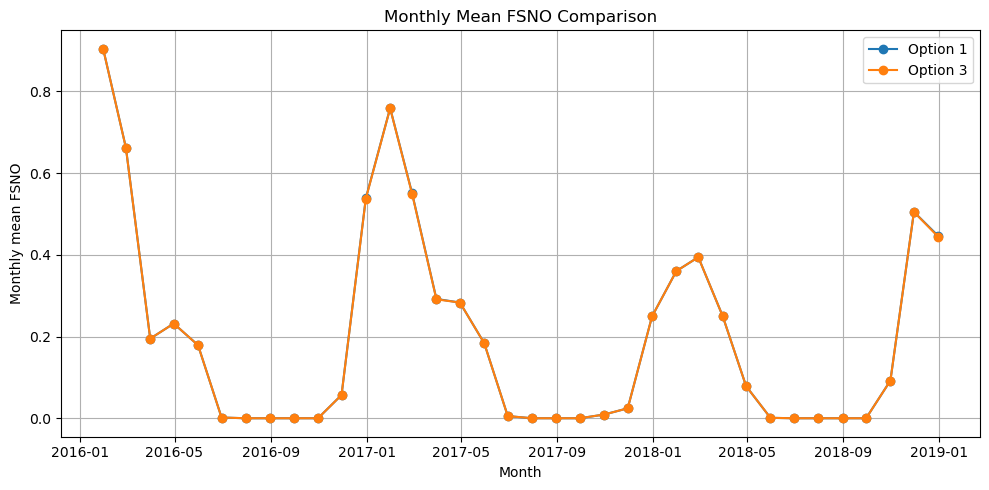

In [8]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#plot monthly mean partition options 1 and 3 to see difference

f1 = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_1/MSWX_3h_Snow_Project3_3d/output_data/1/2016-01-01.nc"
f3 = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_3d/output_data/1/2016-01-01.nc"

def get_monthly_fsno(fp):
    data = xr.open_dataset(fp, group="data", engine="netcdf4")
    meta = xr.open_dataset(fp, group="metadata", engine="netcdf4")

    t = pd.to_datetime(meta["date"].values)
    y = data["fsno"].mean(dim="hru").values

    mask = ~pd.isna(t)
    s = pd.Series(y[mask], index=t[mask]).sort_index()

    data.close()
    meta.close()

    return s.resample("ME").mean()

fsno1_m = get_monthly_fsno(f1)
fsno3_m = get_monthly_fsno(f3)

plt.figure(figsize=(10,5))
plt.plot(fsno1_m.index, fsno1_m.values, marker="o", label="Option 1")
plt.plot(fsno3_m.index, fsno3_m.values, marker="o", label="Option 3")

plt.xlabel("Month")
plt.ylabel("Monthly mean FSNO")
plt.title("Monthly Mean FSNO Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

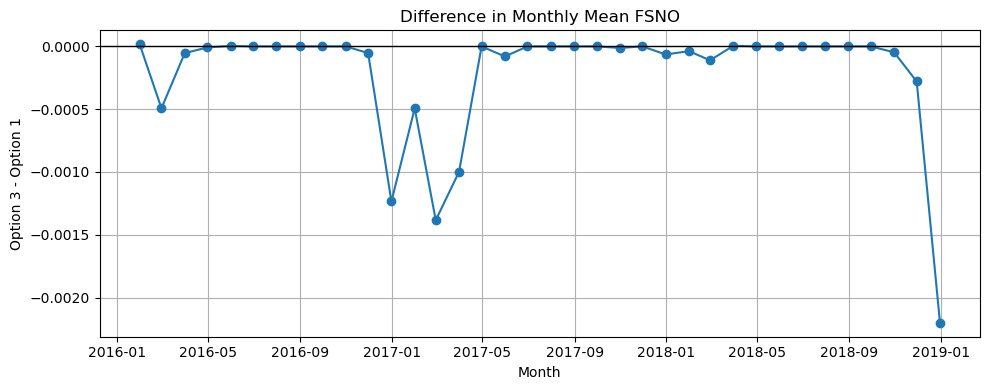

In [9]:
diff = fsno3_m - fsno1_m

plt.figure(figsize=(10,4))
plt.plot(diff.index, diff.values, marker="o")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Month")
plt.ylabel("Option 3 - Option 1")
plt.title("Difference in Monthly Mean FSNO")
plt.grid(True)
plt.tight_layout()
plt.show()

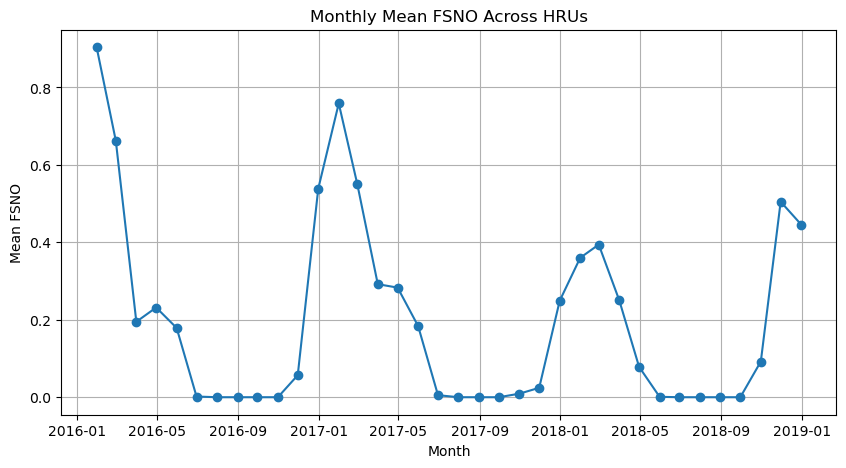

In [10]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

f = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_1/MSWX_3h_Snow_Project3_3d/output_data/1/2016-01-01.nc"

data = xr.open_dataset(f, group="data", engine="netcdf4")
meta = xr.open_dataset(f, group="metadata", engine="netcdf4")

# convert time
t = pd.to_datetime(meta["date"].values)

# mean across HRUs
fsno_mean = data["fsno"].mean(dim="hru").values

# build time series
df = pd.DataFrame({"fsno": fsno_mean}, index=t)

# monthly mean
fsno_monthly = df.resample("ME").mean()

plt.figure(figsize=(10,5))
plt.plot(fsno_monthly.index, fsno_monthly["fsno"], marker="o")

plt.xlabel("Month")
plt.ylabel("Mean FSNO")
plt.title("Monthly Mean FSNO Across HRUs")
plt.grid(True)

plt.show()

data.close()
meta.close()

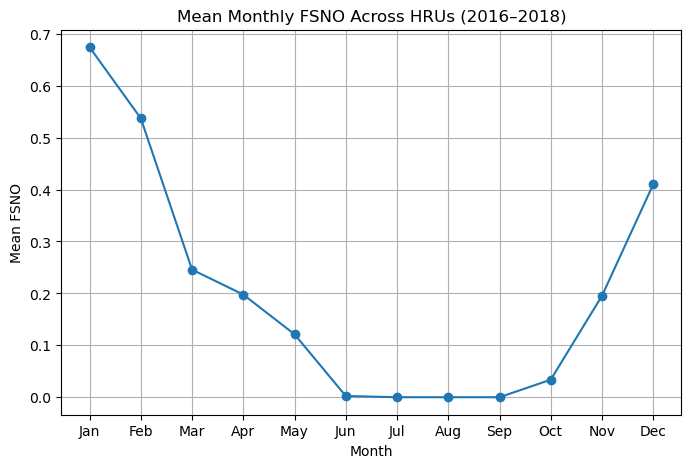

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# df already contains the HRU-mean FSNO time series
# index = datetime, column = fsno

# remove NaT times
df = df[~df.index.isna()]

# group by month and take mean (skip NaN automatically)
fsno_month_clim = df.groupby(df.index.month).mean()

# month labels
months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(8,5))
plt.plot(range(1,13), fsno_month_clim["fsno"], marker="o")

plt.xticks(range(1,13), months)
plt.xlabel("Month")
plt.ylabel("Mean FSNO")
plt.title("Mean Monthly FSNO Across HRUs (2016–2018)")
plt.grid(True)

plt.show()

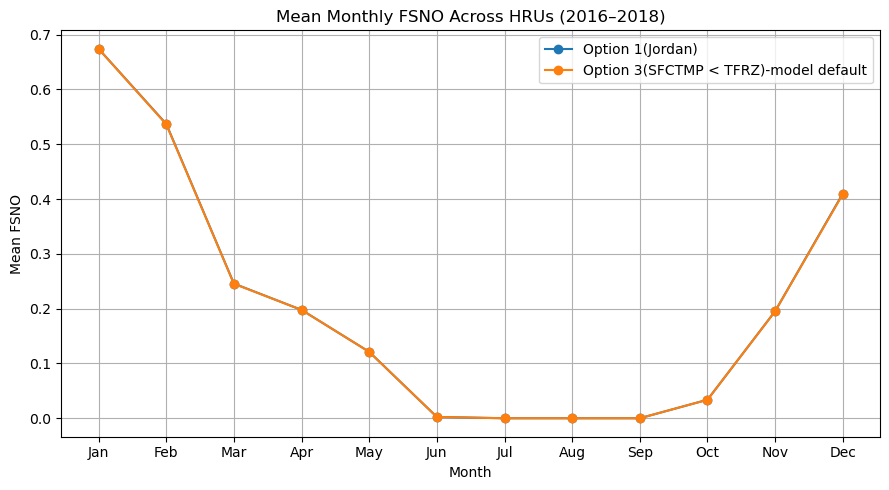

In [12]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

f1 = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_1/MSWX_3h_Snow_Project3_3d/output_data/1/2016-01-01.nc"
f3 = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_3d/output_data/1/2016-01-01.nc"

def monthly_fsno_climatology(fp):
    data = xr.open_dataset(fp, group="data", engine="netcdf4")
    meta = xr.open_dataset(fp, group="metadata", engine="netcdf4")

    t = pd.to_datetime(meta["date"].values, errors="coerce")
    fsno_mean = data["fsno"].mean(dim="hru").values

    df = pd.DataFrame({"fsno": fsno_mean}, index=t)
    df = df[~df.index.isna()]

    clim = df.groupby(df.index.month)["fsno"].mean()

    data.close()
    meta.close()
    return clim

clim1 = monthly_fsno_climatology(f1)
clim3 = monthly_fsno_climatology(f3)

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(9,5))
plt.plot(range(1, 13), clim1.reindex(range(1, 13)), marker="o", label="Option 1(Jordan)")
plt.plot(range(1, 13), clim3.reindex(range(1, 13)), marker="o", label="Option 3(SFCTMP < TFRZ)-model default")

plt.xticks(range(1, 13), months)
plt.xlabel("Month")
plt.ylabel("Mean FSNO")
plt.title("Mean Monthly FSNO Across HRUs (2016–2018)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

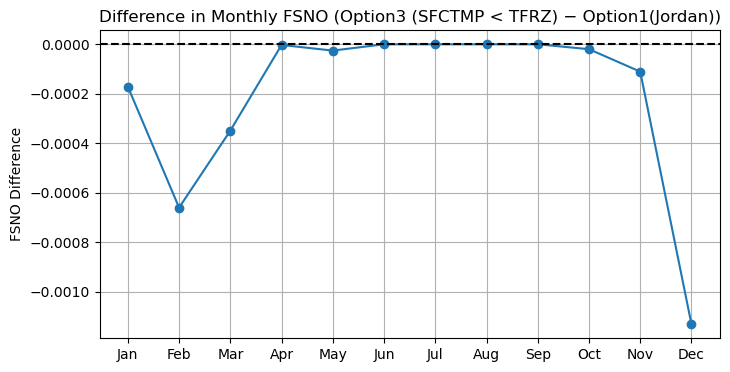

In [13]:
diff = clim3 - clim1

months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(8,4))
plt.plot(range(1,13), diff, marker="o")

plt.axhline(0, color="black", linestyle="--")

plt.xticks(range(1,13), months)
plt.ylabel("FSNO Difference")
plt.title("Difference in Monthly FSNO (Option3 (SFCTMP < TFRZ) − Option1(Jordan))")
plt.grid(True)

plt.show()

In [14]:
import os
import pandas as pd
#from buildforcing.datasets import PNNLSnotel

#os.environ['SNOTEL PATH'] = '/pl/active/snotelmodelling/snotel/'

snotel_path = "/pl/active/snotelmodelling/snotel/"

# stations INSIDE  HydroBlocks domain
stations_in_domain = [
    "Elk Cabin",
    "Santa Fe",
    "Wesner Springs",
    "Quemazon",
    "Rio Santa Barbara",
    "Tres Ritos",
    "Palo",
    "Tolby"
]

all_swe = []

for st in stations_in_domain:
    try:
        s = PNNLSnotel(st, snotel_path)
        s.load_data()

        df = s.data.copy()

        # keep only SWE
        df = df[["swe_mm"]].copy()

        # keep station name
        df["station"] = st

        # convert index to column
        df = df.reset_index().rename(columns={"index": "Date"})

        # convert to datetime
        df["Date"] = pd.to_datetime(df["Date"])

        # filter 2016–2018
        df = df[
            (df["Date"] >= "2016-01-01") &
            (df["Date"] <= "2018-12-31")
        ]

        # drop missing
        df = df.dropna(subset=["swe_mm"])

        all_swe.append(df)

        print(f"Loaded {st}: {df.shape}")

    except Exception as e:
        print(f"FAILED {st}: {e}")

# combine all stations
snotel_swe = pd.concat(all_swe, ignore_index=True)

snotel_swe.head

Loaded Elk Cabin: (1096, 3)
Loaded Santa Fe: (1096, 3)
Loaded Wesner Springs: (1096, 3)
Loaded Quemazon: (731, 3)
Loaded Rio Santa Barbara: (1096, 3)
Loaded Tres Ritos: (1096, 3)
Loaded Palo: (1096, 3)
Loaded Tolby: (1096, 3)


<bound method NDFrame.head of                           Date  swe_mm    station
0    2016-01-01 00:00:00-07:00   53.34  Elk Cabin
1    2016-01-02 00:00:00-07:00   53.34  Elk Cabin
2    2016-01-03 00:00:00-07:00   53.34  Elk Cabin
3    2016-01-04 00:00:00-07:00   53.34  Elk Cabin
4    2016-01-05 00:00:00-07:00   55.88  Elk Cabin
...                        ...     ...        ...
8398 2018-12-27 00:00:00-07:00   93.98      Tolby
8399 2018-12-28 00:00:00-07:00   96.52      Tolby
8400 2018-12-29 00:00:00-07:00   96.52      Tolby
8401 2018-12-30 00:00:00-07:00   96.52      Tolby
8402 2018-12-31 00:00:00-07:00   96.52      Tolby

[8403 rows x 3 columns]>

In [15]:
snotel_swe_wide = snotel_swe.pivot_table(
    index="Date",
    columns="station",
    values="swe_mm"
)

snotel_swe_wide.head()

station,Elk Cabin,Palo,Quemazon,Rio Santa Barbara,Santa Fe,Tolby,Tres Ritos,Wesner Springs
Date,,,,,,,,
2016-01-01 00:00:00-07:00,53.34,78.74,132.08,266.7,297.18,127.0,60.96,259.08
2016-01-02 00:00:00-07:00,53.34,78.74,132.08,266.7,299.72,127.0,60.96,259.08
2016-01-03 00:00:00-07:00,53.34,78.74,132.08,266.7,299.72,127.0,60.96,259.08
2016-01-04 00:00:00-07:00,53.34,78.74,134.62,266.7,299.72,127.0,60.96,261.62
2016-01-05 00:00:00-07:00,55.88,78.74,137.16,266.7,302.26,127.0,60.96,261.62


In [16]:
# use the dataframe you already created
df = snotel_swe.copy()

# ensure datetime
df["Date"] = pd.to_datetime(df["Date"])

# set index
df = df.set_index("Date")

# mean across stations
snotel_mean = df.groupby("Date")["swe_mm"].mean()

In [17]:
import xarray as xr
import glob

hb_path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_pp/output_data/1/"

files = sorted(glob.glob(hb_path + "*.nc"))

# open ONLY the data group
ds = xr.open_mfdataset(
    files,
    group="data",
    combine="by_coords"
)

print(ds)
print(list(ds.data_vars))

<xarray.Dataset> Size: 909MB
Dimensions:  (time: 8744, hru: 1000, snow: 3, soil: 10)
Dimensions without coordinates: time, hru, snow, soil
Data variables: (12/15)
    qsnow    (time, hru) float32 35MB dask.array<chunksize=(8744, 1000), meta=np.ndarray>
    totsmc   (time, hru) float32 35MB dask.array<chunksize=(8744, 1000), meta=np.ndarray>
    swe      (time, hru) float32 35MB dask.array<chunksize=(8744, 1000), meta=np.ndarray>
    snow_t   (time, hru, snow) float32 105MB dask.array<chunksize=(8744, 1000, 3), meta=np.ndarray>
    snowh    (time, hru) float32 35MB dask.array<chunksize=(8744, 1000), meta=np.ndarray>
    fsno     (time, hru) float32 35MB dask.array<chunksize=(8744, 1000), meta=np.ndarray>
    ...       ...
    swnet    (time, hru) float32 35MB dask.array<chunksize=(8744, 1000), meta=np.ndarray>
    lwdn     (time, hru) float32 35MB dask.array<chunksize=(8744, 1000), meta=np.ndarray>
    lwnet    (time, hru) float32 35MB dask.array<chunksize=(8744, 1000), meta=np.ndarray>

In [18]:
import pandas as pd

time = ds["time"].values   # this is integer hours

start = pd.Timestamp("2016-01-01 00:00")

datetime_series = start + pd.to_timedelta(time, unit="h")

#  timezone handling
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")

hb_swe = ds["swe"]
hb_swe = hb_swe.assign_coords(time=datetime_series)

hb_swe_daily = hb_swe.resample(time="1D").mean()

time
2015-12-31 00:00:00-07:00    0.163122
2016-01-01 00:00:00-07:00    0.279762
2016-01-02 00:00:00-07:00    1.360721
2016-01-03 00:00:00-07:00    7.892182
2016-01-04 00:00:00-07:00    9.972291
Freq: D, Name: swe, dtype: float32
Date
2016-01-01 00:00:00-07:00    159.3850
2016-01-02 00:00:00-07:00    159.7025
2016-01-03 00:00:00-07:00    159.7025
2016-01-04 00:00:00-07:00    160.3375
2016-01-05 00:00:00-07:00    161.2900
Name: swe_mm, dtype: float64
                              HB_SWE  SNOTEL_MEAN_SWE
2016-01-01 00:00:00-07:00   0.279762         159.3850
2016-01-02 00:00:00-07:00   1.360721         159.7025
2016-01-03 00:00:00-07:00   7.892182         159.7025
2016-01-04 00:00:00-07:00   9.972291         160.3375
2016-01-05 00:00:00-07:00  10.006300         161.2900


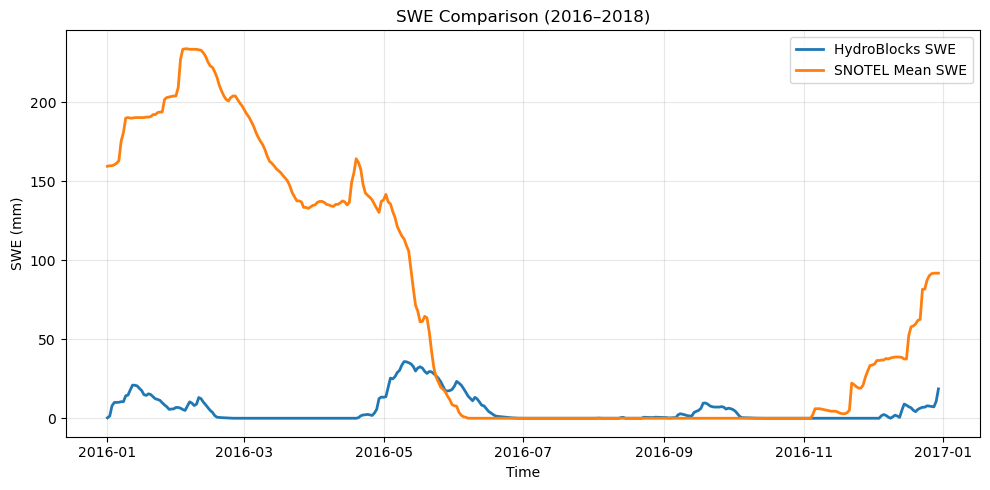

In [19]:
# HydroBlocks daily mean SWE across HRUs
hb_daily_mean = hb_swe_daily.mean(dim="hru").to_pandas()

#  check
print(hb_daily_mean.head())

# SNOTEL mean across stations
df = snotel_swe.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

snotel_mean = df.groupby("Date")["swe_mm"].mean()

# check data
print(snotel_mean.head())

# Combine
common = pd.concat([hb_daily_mean, snotel_mean], axis=1)
common.columns = ["HB_SWE", "SNOTEL_MEAN_SWE"]
common = common.dropna()

print(common.head())

# Plot
plt.figure(figsize=(10,5))
plt.plot(common.index, common["HB_SWE"], label="HydroBlocks SWE", linewidth=2)
plt.plot(common.index, common["SNOTEL_MEAN_SWE"], label="SNOTEL Mean SWE", linewidth=2)

plt.legend()
plt.grid(alpha=0.3)
plt.xlabel("Time")
plt.ylabel("SWE (mm)")
plt.title("SWE Comparison (2016–2018)")
plt.tight_layout()
plt.show()

In [20]:
# MONTHLY MEAN SWE COMPARISON: HB vs SNOTEL
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt


hb_monthly = hb_swe_daily.resample(time="ME").mean()    # ME; Month End frequency

# mean across all HRUs
hb_monthly_mean = hb_monthly.mean(dim="hru").to_pandas()

# remove timezone if present
#error; Cannot compare tz-naive and tz-aware timestamps; because HydroBlocks time has timezone but SNOTEL time has no timezone
hb_monthly_mean.index = pd.to_datetime(hb_monthly_mean.index).tz_localize(None)


#  SNOTEL MONTHLY MEAN SWE
# snotel_swe is assumed to already exist with columns:
# Date, swe_mm, station

df = snotel_swe.copy()  # make separate/independent copy of SNOTEL data, (point to different object in memory)

df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

# mean across stations for each day
snotel_daily_mean = df.groupby("Date")["swe_mm"].mean()

# monthly mean
snotel_monthly = snotel_daily_mean.resample("ME").mean()

# remove timezone if present
snotel_monthly.index = pd.to_datetime(snotel_monthly.index).tz_localize(None)


# ALIGN HB AND SNOTEL MONTHLY SERIES
common_m = pd.concat([hb_monthly_mean, snotel_monthly], axis=1)
common_m.columns = ["HB_SWE", "SNOTEL_MEAN_SWE"]

common_m = common_m.dropna()

print(common_m.head())


# PLOT MONTHLY MEAN TIME SERIES
plt.figure(figsize=(10, 5))gi

plt.plot(common_m.index, common_m["HB_SWE"], marker="o", label="HydroBlocks SWE")
plt.plot(common_m.index, common_m["SNOTEL_MEAN_SWE"], marker="o", label="SNOTEL Mean SWE")

plt.xlabel("Time")
plt.ylabel("SWE (mm)")
plt.title("Monthly Mean SWE Comparison (2016–2018)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (1872453354.py, line 47)

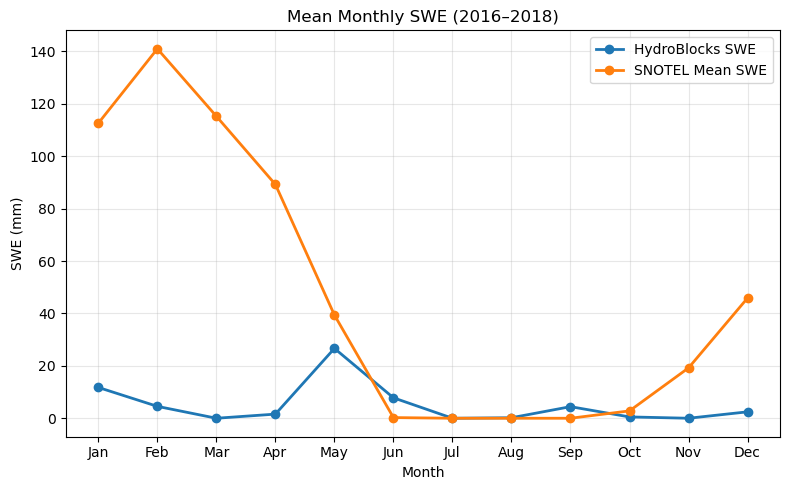

In [ ]:
# ==========================================
# MONTHLY MEAN (CLIMATOLOGY) SWE: 2016–2018
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# HYDROBLOCKS  monthly climatology

hb_monthly = hb_swe_daily.resample(time="ME").mean()

# mean across HRUs
hb_monthly_mean = hb_monthly.mean(dim="hru").to_pandas()

# remove timezone if present
hb_monthly_mean.index = pd.to_datetime(hb_monthly_mean.index).tz_localize(None)

# get climatology (mean for each month across years)
hb_clim = hb_monthly_mean.groupby(hb_monthly_mean.index.month).mean()


# SNOTEL monthly climatology
df = snotel_swe.copy()

df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

# mean across stations per day
snotel_daily = df.groupby("Date")["swe_mm"].mean()

# monthly mean
snotel_monthly = snotel_daily.resample("ME").mean()

# remove timezone 
snotel_monthly.index = pd.to_datetime(snotel_monthly.index).tz_localize(None)

# climatology
snotel_clim = snotel_monthly.groupby(snotel_monthly.index.month).mean()


# PLOT 
months = range(1, 13)

plt.figure(figsize=(8,5))

plt.plot(months, hb_clim.values, marker="o", linewidth=2, label="HydroBlocks SWE")
plt.plot(months, snotel_clim.values, marker="o", linewidth=2, label="SNOTEL Mean SWE")

plt.xticks(months, ["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])

plt.xlabel("Month")
plt.ylabel("SWE (mm)")
plt.title("Mean Monthly SWE (2016–2018)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print(snotel_swe.columns.tolist())
print(snotel_swe.head())

['Date', 'swe_mm', 'station']
                       Date  swe_mm    station
0 2016-01-01 00:00:00-07:00   53.34  Elk Cabin
1 2016-01-02 00:00:00-07:00   53.34  Elk Cabin
2 2016-01-03 00:00:00-07:00   53.34  Elk Cabin
3 2016-01-04 00:00:00-07:00   53.34  Elk Cabin
4 2016-01-05 00:00:00-07:00   55.88  Elk Cabin


In [ ]:
# swe map plot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# ----------------------------
# variable
# ----------------------------
snow = ds_all["snow_fraction"]

# ----------------------------
# HydroBlocks/MSWX raster info
# ----------------------------
xmin = -106.45041666666549
xmax = -104.94958333333221
ymin = 35.049583333332606
ymax = 36.55041666666588
nx   = 1801
ny   = 1801

buffer = 250

# same coordinate construction style as MSWX
coord_xx0 = np.linspace(xmin, xmax, nx)
coord_yy0 = np.linspace(ymin, ymax, ny)

coords_x = coord_xx0[buffer:len(coord_xx0)-buffer+1]
coords_y = coord_yy0[buffer:len(coord_yy0)-buffer+1]

print("cropped x range:", coords_x[0], coords_x[-1])
print("cropped y range:", coords_y[0], coords_y[-1])

# ----------------------------
# seasonal climatology
# ----------------------------
seasonal = snow.groupby("time.season").mean("time", skipna=True)

seasons = ["DJF", "MAM", "JJA", "SON"]
titles  = ["Winter", "Spring", "Summer", "Fall"]

# ----------------------------
# colormap
# ----------------------------
cmap = plt.cm.viridis.copy()
cmap.set_bad(color=cmap(0.0))
norm = colors.Normalize(vmin=0, vmax=100)

# ----------------------------
# plot
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, season in enumerate(seasons):
    da = seasonal.sel(season=season).values

    # same crop as MSWX
    da_crop = da[buffer:da.shape[0]-buffer+1,
                 buffer:da.shape[1]-buffer+1]

    # optional: mask invalid values
    da_crop = np.ma.masked_invalid(da_crop)

    im = axes[i].pcolormesh(
        coords_x,
        coords_y,
        np.flipud(da_crop),
        cmap=cmap,
        norm=norm,
        shading="auto"
    )

    axes[i].set_title(f"MODSCAG Snow Fraction – {titles[i]}")
    axes[i].set_xlabel("Longitude")
    axes[i].set_ylabel("Latitude")

    fig.colorbar(im, ax=axes[i], label="Snow Fraction [%]")

plt.tight_layout()
plt.show()

EXTRACT STATIONS WITHIN DOMAIN BOUNDS FROM SNOTEL

In [14]:
import pandas as pd

# Load station summary
stations = pd.read_csv(
    "/pl/active/snotelmodelling/snotel/bcqc_data_v2/SNOTEL_summary.csv"
)

# Domain bounds
lon_min = -106.45041666666549
lon_max = -104.94958333333221

lat_min = 35.049583333332606
lat_max = 36.55041666666588

# Select stations inside domain
stations_domain = stations[
    (stations["SNOTEL Lon ()"] >= lon_min) &
    (stations["SNOTEL Lon ()"] <= lon_max) &
    (stations["SNOTEL Lat ()"] >= lat_min) &
    (stations["SNOTEL Lat ()"] <= lat_max)
].copy()

# Reset index
stations_domain = stations_domain.reset_index(drop=True)

# Print results
print("Stations in domain:", len(stations_domain))

display(
    stations_domain[
        [
            "SNOTEL ID",
            "SNOTEL Name",
            "SNOTEL State",
            "SNOTEL Lat ()",
            "SNOTEL Lon ()",
            "SNOTEL Elev (ft)"
        ]
    ]
)

Stations in domain: 10


,SNOTEL ID,SNOTEL Name,SNOTEL State,SNOTEL Lat (),SNOTEL Lon (),SNOTEL Elev (ft)
0,1083,Tres Ritos,NM,36.13,-105.53,8600
1,1170,Palo,NM,36.41,-105.33,9350
2,1254,Rio Santa Barbara,NM,36.07,-105.63,10664
3,316,Bateman,NM,36.51,-106.32,9300
4,491,Gallegos Peak,NM,36.19,-105.56,9800
5,708,Quemazon,NM,35.92,-106.39,9500
6,854,Wesner Springs,NM,35.78,-105.54,11120
7,921,Elk Cabin,NM,35.70,-105.81,8210
8,922,Santa Fe,NM,35.77,-105.78,11445
9,934,Tolby,NM,36.47,-105.19,10180


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --------------------------------------------------
# HB DOMAIN
# --------------------------------------------------
lon_min = -106.45041666666549
lon_max = -104.94958333333221
lat_min = 35.049583333332606
lat_max = 36.55041666666588

# --------------------------------------------------
# PREPARE DATA
# --------------------------------------------------
df = snotel_df.copy()
df.columns = df.columns.str.lower().str.strip()

stations_domain2 = stations_domain.copy()
stations_domain2.columns = stations_domain2.columns.str.lower().str.strip()

stations_domain2 = stations_domain2.rename(columns={
    "snotel name": "station",
    "snotel lat ()": "latitude",
    "snotel lon ()": "longitude",
    "snotel elev (ft)": "elev_ft"
})

df["station"] = df["station"].astype(str).str.strip()
stations_domain2["station"] = stations_domain2["station"].astype(str).str.strip()

df_domain = df.merge(
    stations_domain2[["station", "latitude", "longitude", "elev_ft"]],
    on="station",
    how="inner"
)

df_domain["date"] = pd.to_datetime(df_domain["date"])

df_domain = df_domain[
    (df_domain["date"] >= "2016-01-01") &
    (df_domain["date"] <= "2018-12-31")
].copy()

# --------------------------------------------------
# SEASONS
# --------------------------------------------------
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df_domain["season"] = df_domain["date"].dt.month.apply(get_season)

season_order = ["Winter", "Spring", "Summer", "Fall"]

seasonal_swe = (
    df_domain
    .groupby(["station", "season", "latitude", "longitude"])["swe_mm"]
    .mean()
    .reset_index()
)

# --------------------------------------------------
# PLOT STATION-BASED SWE MAP
# --------------------------------------------------
vmin = 0
vmax = seasonal_swe["swe_mm"].max()

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

axes = axes.flatten()

for i, season in enumerate(season_order):
    ax = axes[i]

    sub = seasonal_swe[seasonal_swe["season"] == season].copy()

    ax.set_extent(
        [lon_min, lon_max, lat_min, lat_max],
        crs=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.35)
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

    sc = ax.scatter(
        sub["longitude"],
        sub["latitude"],
        c=sub["swe_mm"],
        cmap="Blues",
        s=90,
        edgecolor="black",
        linewidth=0.6,
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    for _, row in sub.iterrows():
        ax.text(
            row["longitude"] + 0.015,
            row["latitude"] + 0.015,
            row["station"],
            fontsize=7,
            transform=ccrs.PlateCarree()
        )

    ax.set_title(f"{season} mean SNOTEL SWE (2016–2018)")

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

cbar = fig.colorbar(
    sc,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08
)
cbar.set_label("SWE [mm]")

plt.suptitle("Seasonal Mean SNOTEL SWE Stations within HydroBlocks Domain", fontsize=14)
plt.show()

KeyError: 'date'

In [17]:
import os
import numpy as np
import pandas as pd
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import rasterio

# --------------------------------------------------
# PATHS
# --------------------------------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/"

path_model = path_pp   # change to path_3d if needed

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/SNOTEL_SWE_compare"
os.makedirs(outputdir, exist_ok=True)

# --------------------------------------------------
# BUFFER
# --------------------------------------------------
buffer = 0

# --------------------------------------------------
# READ HRU/CID MAPS USING RASTERIO
# --------------------------------------------------
with rasterio.open(path_model + "postprocess/hrus.vrt") as src:
    hrus = src.read(1)
    bounds = src.bounds
    nx = src.width
    ny = src.height

with rasterio.open(path_model + "postprocess/cids.vrt") as src:
    cids = src.read(1)

tmp = np.copy(hrus).astype(float)
tmp[:] = -9999.0

coord_xx0 = np.linspace(bounds.left, bounds.right, nx)
coord_yy0 = np.linspace(bounds.bottom, bounds.top, ny)

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

# --------------------------------------------------
# FUNCTION: HRU TO GRID
# --------------------------------------------------
def place_data(tmp, model, hrus, cids, cid_val=1):
    out = np.copy(tmp)
    nhru = len(model)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (ucid == cid_val) and (hru > 0) and (hru <= nhru):
                out[i, j] = model[hru - 1]

    return out

# --------------------------------------------------
# READ MODEL SWE
# --------------------------------------------------
fp = nc.Dataset(path_model + "/output_data/1/2016-01-01.nc")
swe_model = np.array(fp.groups["data"].variables["swe"][:])
fp.close()

ntime = swe_model.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3h")
# --------------------------------------------------
# PREPARE SNOTEL DATA
# --------------------------------------------------
df = snotel_df.copy()
df.columns = df.columns.str.lower().str.strip()

stations_domain2 = stations_domain.copy()
stations_domain2.columns = stations_domain2.columns.str.lower().str.strip()

stations_domain2 = stations_domain2.rename(columns={
    "snotel name": "station",
    "snotel lat ()": "latitude",
    "snotel lon ()": "longitude",
    "snotel elev (ft)": "elev_ft"
})

df["station"] = df["station"].astype(str).str.strip()
stations_domain2["station"] = stations_domain2["station"].astype(str).str.strip()

df_domain = df.merge(
    stations_domain2[["station", "latitude", "longitude", "elev_ft"]],
    on="station",
    how="inner"
)

df_domain["date"] = pd.to_datetime(df_domain["date"]).dt.tz_localize(None)

df_domain = df_domain[
    (df_domain["date"] >= "2016-01-01") &
    (df_domain["date"] <= "2018-12-31")
].copy()

# --------------------------------------------------
# SEASONS
# --------------------------------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]

season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall": [9, 10, 11]
}

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df_domain["season"] = df_domain["date"].dt.month.apply(get_season)

snotel_seasonal = (
    df_domain
    .groupby(["station", "season", "latitude", "longitude"])["swe_mm"]
    .mean()
    .reset_index()
)

# --------------------------------------------------
# FUNCTION: SAMPLE MODEL GRID AT STATION LOCATION
# --------------------------------------------------
def sample_grid_at_points(grid, lons, lats, coords_x, coords_y):
    vals = []

    for lon, lat in zip(lons, lats):
        ix = np.argmin(np.abs(coords_x - lon))
        iy = np.argmin(np.abs(coords_y - lat))
        vals.append(grid[iy, ix])

    return np.array(vals)

# --------------------------------------------------
# BUILD SEASONAL MODEL MAPS AND STATION BIASES
# --------------------------------------------------
all_bias = []
season_data = {}

for season in seasons:
    months = season_months[season]

    mask = times.month.isin(months)

    swe_mean_hru = np.nanmean(
        swe_model[mask, :],
        axis=0
    )

    model_map = place_data(
        tmp,
        swe_mean_hru,
        hrus,
        cids,
        1
    )

    model_map = np.where(
        model_map == -9999.0,
        np.nan,
        model_map
    )

    model_map = model_map[
        buffer:model_map.shape[0] - buffer + 1,
        buffer:model_map.shape[1] - buffer + 1
    ]

    sub = snotel_seasonal[
        snotel_seasonal["season"] == season
    ].copy()

    model_at_station = sample_grid_at_points(
        model_map,
        sub["longitude"].values,
        sub["latitude"].values,
        coords_x,
        coords_y
    )

    sub["model_swe_mm"] = model_at_station
    sub["bias_mm"] = sub["model_swe_mm"] - sub["swe_mm"]

    all_bias.extend(
        sub["bias_mm"].dropna().values
    )

    season_data[season] = (model_map, sub)

# --------------------------------------------------
# COLOR LIMITS
# --------------------------------------------------
bias_vmax = np.nanmax(np.abs(all_bias))

if not np.isfinite(bias_vmax) or bias_vmax == 0:
    bias_vmax = 1.0

bias_norm = colors.TwoSlopeNorm(
    vmin=-bias_vmax,
    vcenter=0,
    vmax=bias_vmax
)

model_vmax = max([
    np.nanmax(season_data[s][0])
    for s in seasons
])

# --------------------------------------------------
# PLOT
# --------------------------------------------------
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)

axes = axes.flatten()

for i, season in enumerate(seasons):
    ax = axes[i]

    model_map, sub = season_data[season]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(model_map),
        cmap="viridis",
        shading="auto",
        vmin=0,
        vmax=model_vmax
    )

    sc = ax.scatter(
        sub["longitude"],
        sub["latitude"],
        c=sub["bias_mm"],
        cmap="bwr",
        norm=bias_norm,
        s=80,
        edgecolor="black",
        linewidth=0.7
    )

    for _, row in sub.iterrows():
        ax.text(
            row["longitude"] + 0.01,
            row["latitude"] + 0.01,
            row["station"],
            fontsize=6
        )

    ax.set_title(f"Model SWE with SNOTEL bias | {season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

cbar1 = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.04,
    pad=0.08
)
cbar1.set_label("Model SWE [mm]")

cbar2 = fig.colorbar(
    sc,
    ax=axes,
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)
cbar2.set_label("Model - SNOTEL SWE [mm]")

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    "model_SWE_map_with_SNOTEL_bias_points.png"
)

plt.savefig(
    outfile,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", outfile)

# --------------------------------------------------
# PRINT STATION METRICS
# --------------------------------------------------
bias_rows = []

for season in seasons:
    _, sub = season_data[season]

    valid = np.isfinite(sub["bias_mm"])

    bias_rows.append({
        "season": season,
        "mean_bias_mm": np.nanmean(sub.loc[valid, "bias_mm"]),
        "mae_mm": np.nanmean(np.abs(sub.loc[valid, "bias_mm"])),
        "rmse_mm": np.sqrt(np.nanmean(sub.loc[valid, "bias_mm"]**2)),
        "n_stations": valid.sum()
    })

bias_df = pd.DataFrame(bias_rows)

display(bias_df)

KeyError: 'date'

In [1]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

hrus = gdal_tools.read_raster(hrus_file).astype(np.int32)
cids = gdal_tools.read_raster(cids_file).astype(np.int32)
metad = gdal_tools.retrieve_metadata(hrus_file)

extent = [metad["minx"], metad["maxx"], metad["miny"], metad["maxy"]]

var = "precip"   # try "tair" or "swdown" also
season_name = "Winter"
cid_list = range(1, 1601)

time_file = path + "1/input_file.nc"

with nc.Dataset(time_file) as fp:
    time = fp.groups["meteorology"].variables["time"][:]

start = pd.Timestamp("2014-01-01 00:00:00")
times = pd.Series(start + pd.to_timedelta(time, unit="h"), name="datetime")

season_index = (
    (times.dt.year == 2014) &
    (times.dt.month.isin([1, 2]))
).values

print("Total timesteps:", len(times))
print("Selected timesteps:", season_index.sum())

final_map = np.full(hrus.shape, -9999.0, dtype=np.float32)

for cid in cid_list:

    if cid % 50 == 0:
        print(f"Processing CID {cid}", flush=True)

    fp_path = path + f"{cid}/input_file.nc"

    if not os.path.exists(fp_path):
        continue

    with nc.Dataset(fp_path) as fp:
        grp = fp.groups["meteorology"]

        if var not in grp.variables:
            continue

        # meteorology variable shape is usually time x hru
        vals = np.array(grp.variables[var][:], dtype=np.float32)

    vals[vals <= -9990] = np.nan

    data = np.nanmean(vals[season_index, :], axis=0)

    if var == "precip":
        # convert mean precip rate to approximate mm/day
        data = data * 86400.0

    mask = (hrus != -9999) & (cids == cid)

    hru_ids = hrus[mask].astype(np.int32)

    # HRU raster values are usually 1-based
    hru_index = hru_ids - 1

    valid = (hru_index >= 0) & (hru_index < len(data))

    rows, cols = np.where(mask)

    final_map[rows[valid], cols[valid]] = data[hru_index[valid]]

final_map[final_map == -9999.0] = np.nan

print("Final min:", np.nanmin(final_map))
print("Final max:", np.nanmax(final_map))

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    final_map,
    origin="upper",
    extent=extent,
    cmap="viridis",
    interpolation="nearest"
)

ax.set_title(f"{var.upper()} - {season_name} 2014 mean")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

label = "Precip [mm/day]" if var == "precip" else var
plt.colorbar(im, ax=ax, label=label)

outfile = os.path.join(
    outputdir,
    f"{var}_{season_name}_2014_forcing_HRU_mapped.png"
)

plt.savefig(outfile, dpi=250, bbox_inches="tight")
print("Saved:", outfile, flush=True)

plt.show()

Total timesteps: 32120
Selected timesteps: 472
Processing CID 50
Processing CID 100
Processing CID 150
Processing CID 200
Processing CID 250
Processing CID 300
Processing CID 350
Processing CID 400
Processing CID 450
Processing CID 500
Processing CID 550
Processing CID 600
Processing CID 650
Processing CID 700
Processing CID 750
Processing CID 800
Processing CID 850
Processing CID 900
Processing CID 950
Processing CID 1000
Processing CID 1050
Processing CID 1100
Processing CID 1150
Processing CID 1200
Processing CID 1250
Processing CID 1300
Processing CID 1350
Processing CID 1400
Processing CID 1450
Processing CID 1500
Processing CID 1550
Processing CID 1600
Final min: 0.023413463
Final max: 5.7089953


: 

: 

HRU file: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/postprocess/hrus/500.tif
NetCDF file: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/output_data/500/2014-01-01.nc
HRU map shape: (901, 901)
HRU map min/max: -9999 99
Groups: dict_keys(['data', 'metadata'])
Data variables: dict_keys(['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swnet', 'lwdn', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv'])
SMC shape: (32120, 100, 10)
Number of SMC HRUs: 10
SMC min/max: 0.2705078 0.31152344
Reconstructed map min/max: 0.2705078125 0.3115234375


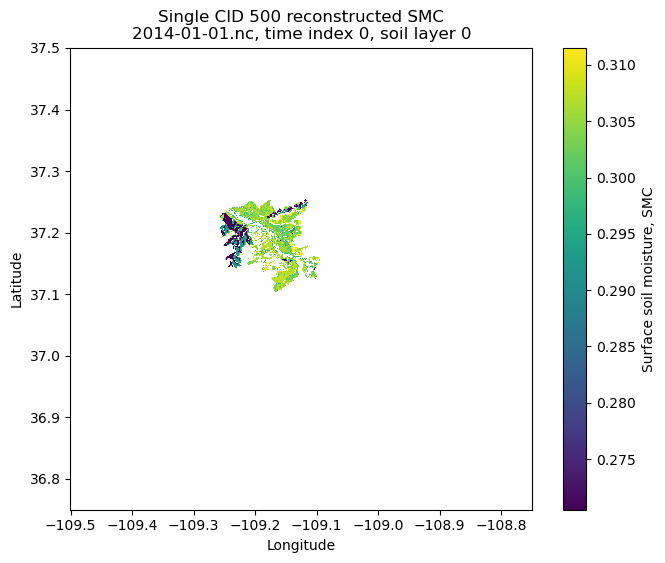

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/single_cid_500_smc_2014-01-01.png


In [2]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# -----------------------------
# SETTINGS
# -----------------------------
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

cid = 500
datefile = "2014-01-01.nc"

itime = 0          # first 3-hour timestep
soil_layer = 0     # top soil layer

# -----------------------------
# FILE PATHS
# -----------------------------
hru_file = path + f"postprocess/hrus/{cid}.tif"
ncfile = path + f"output_data/{cid}/{datefile}"

print("HRU file:", hru_file)
print("NetCDF file:", ncfile)

# -----------------------------
# READ SINGLE CID HRU MAP
# -----------------------------
hru_map = gdal_tools.read_raster(hru_file).astype(np.int32)

meta = gdal_tools.retrieve_metadata(hru_file)
extent = [meta["minx"], meta["maxx"], meta["miny"], meta["maxy"]]

print("HRU map shape:", hru_map.shape)
print("HRU map min/max:", np.nanmin(hru_map), np.nanmax(hru_map))

# -----------------------------
# READ SINGLE CID MODEL OUTPUT
# -----------------------------
with nc.Dataset(ncfile) as ds:
    print("Groups:", ds.groups.keys())
    print("Data variables:", ds["data"].variables.keys())

    smc = ds["data"]["smc"][:]

print("SMC shape:", smc.shape)

# -----------------------------
# EXTRACT ONE TIME + ONE SOIL LAYER
# -----------------------------
# Expected shape: time, soil_layer, hru
smc_hru = smc[itime, soil_layer, :]

print("Number of SMC HRUs:", len(smc_hru))
print("SMC min/max:", np.nanmin(smc_hru), np.nanmax(smc_hru))

# -----------------------------
# RECONSTRUCT SMC MAP FOR ONE CID
# -----------------------------
smc_map = np.full(hru_map.shape, np.nan)

for h in range(1, len(smc_hru) + 1):
    smc_map[hru_map == h] = smc_hru[h - 1]

print("Reconstructed map min/max:", np.nanmin(smc_map), np.nanmax(smc_map))

# -----------------------------
# PLOT SINGLE CID ONLY
# -----------------------------
plt.figure(figsize=(8, 6))

im = plt.imshow(
    smc_map,
    origin="upper",
    extent=extent,
    cmap="viridis",
    interpolation="nearest"
)

plt.colorbar(im, label="Surface soil moisture, SMC")
plt.title(f"Single CID {cid} reconstructed SMC\n{datefile}, time index {itime}, soil layer {soil_layer}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

outfile = outputdir + f"/single_cid_{cid}_smc_{datefile.replace('.nc','')}.png"
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outfile)

In [3]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

cids_to_plot = [459,460,461,499,500,501,539,540,541]

datefile = "2014-01-01.nc"
itime = 0
soil_layer = 0

all_maps = []
all_extents = []

global_min = np.inf
global_max = -np.inf

for cid in cids_to_plot:
    print("Processing CID:", cid, flush=True)

    hru_file = path + f"postprocess/hrus/{cid}.tif"
    ncfile = path + f"output_data/{cid}/{datefile}"

    hru_map = gdal_tools.read_raster(hru_file).astype(np.int32)
    meta = gdal_tools.retrieve_metadata(hru_file)

    extent = [meta["minx"], meta["maxx"], meta["miny"], meta["maxy"]]

    with nc.Dataset(ncfile) as ds:
        smc = ds["data"]["smc"][itime, soil_layer, :]

    smc_map = np.full(hru_map.shape, np.nan)

    for h in range(1, len(smc) + 1):
        smc_map[hru_map == h] = smc[h - 1]

    all_maps.append(smc_map)
    all_extents.append(extent)

    global_min = min(global_min, np.nanmin(smc_map))
    global_max = max(global_max, np.nanmax(smc_map))

    del hru_map, smc_map, smc

print("Global min/max:", global_min, global_max)

plt.figure(figsize=(8, 8))

for smc_map, extent, cid in zip(all_maps, all_extents, cids_to_plot):
    plt.imshow(
        smc_map,
        origin="upper",
        extent=extent,
        cmap="viridis",
        vmin=global_min,
        vmax=global_max,
        interpolation="nearest"
    )

    xmid = (extent[0] + extent[1]) / 2
    ymid = (extent[2] + extent[3]) / 2
    plt.text(xmid, ymid, str(cid), color="red", fontsize=8, ha="center")

plt.colorbar(label="Surface soil moisture, SMC")
plt.title("9-CID reconstructed SMC mosaic")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

outfile = outputdir + "/nine_cid_smc_mosaic_around_500.png"
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outfile)

: 

: 

HRU map shape: (901, 901)
HRU min/max: 1.0 99.0
Unique HRUs: 99


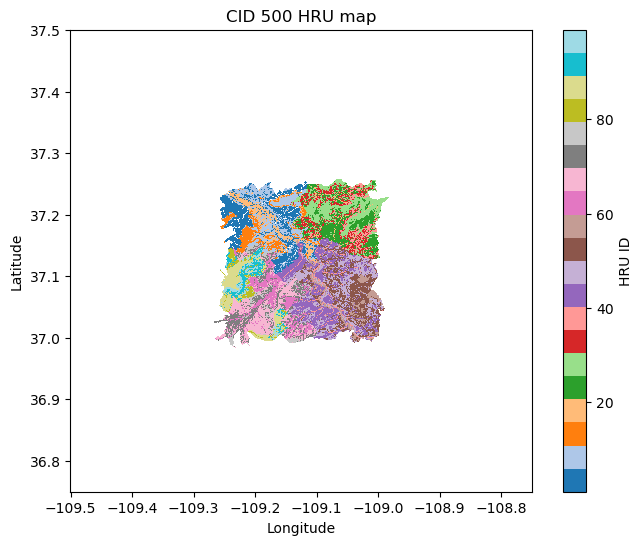

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/single_cid_500_hru_map.png


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

cid = 500

hru_file = path + f"postprocess/hrus/{cid}.tif"

hru_map = gdal_tools.read_raster(hru_file).astype(np.int32)
meta = gdal_tools.retrieve_metadata(hru_file)

extent = [meta["minx"], meta["maxx"], meta["miny"], meta["maxy"]]

hru_plot = hru_map.astype(float)
hru_plot[hru_plot <= 0] = np.nan

print("HRU map shape:", hru_map.shape)
print("HRU min/max:", np.nanmin(hru_plot), np.nanmax(hru_plot))
print("Unique HRUs:", len(np.unique(hru_map[hru_map > 0])))

plt.figure(figsize=(8, 6))

im = plt.imshow(
    hru_plot,
    origin="upper",
    extent=extent,
    cmap="tab20",
    interpolation="nearest"
)

plt.colorbar(im, label="HRU ID")
plt.title(f"CID {cid} HRU map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

outfile = outputdir + f"/single_cid_{cid}_hru_map.png"
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outfile)

CID 500 pixel rows: 8389 8720
CID 500 pixel cols: 5980 6323


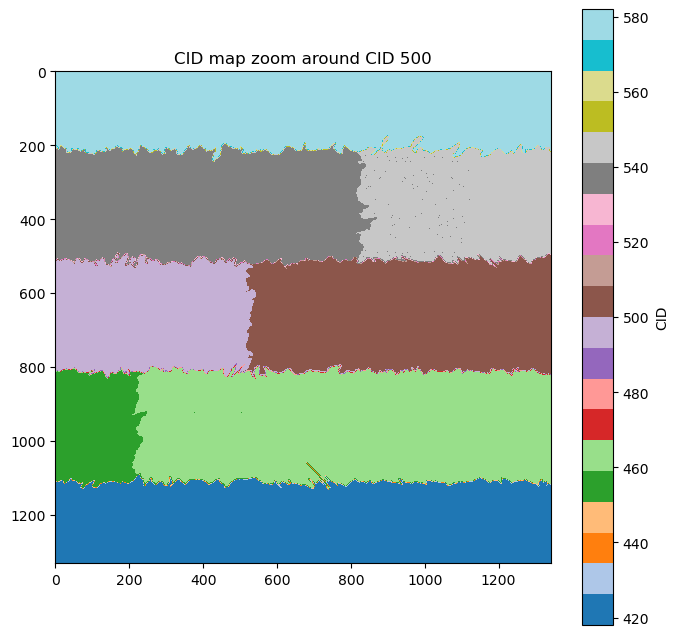

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

cids = gdal_tools.read_raster(path + "postprocess/cids.vrt").astype(float)

cids[cids <= 0] = np.nan
cids[cids == -9999] = np.nan

# zoom to pixels around CID 500
y, x = np.where(cids == 500)

print("CID 500 pixel rows:", y.min(), y.max())
print("CID 500 pixel cols:", x.min(), x.max())

buffer = 500

r0 = max(y.min() - buffer, 0)
r1 = min(y.max() + buffer, cids.shape[0])
c0 = max(x.min() - buffer, 0)
c1 = min(x.max() + buffer, cids.shape[1])

zoom = cids[r0:r1, c0:c1]

plt.figure(figsize=(8, 8))
plt.imshow(zoom, origin="upper", cmap="tab20")
plt.colorbar(label="CID")
plt.title("CID map zoom around CID 500")
plt.show()

Simulation path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
Total timesteps: 32120
First time: 2014-01-01 00:00:00
Last time : 2024-12-28 21:00:00
Winter timesteps: 472
Processing CID 459
CID 459 data min/max: 0.15700932 0.42531574
Processing CID 460
CID 460 data min/max: 0.15700932 0.42531574
Processing CID 461
CID 461 data min/max: 0.15700932 0.42531574
Processing CID 499
CID 499 data min/max: 0.13436425 0.4580699
Processing CID 500
CID 500 data min/max: 0.13436425 0.4580699
Processing CID 501
CID 501 data min/max: 0.13436425 0.4580699
Processing CID 539
CID 539 data min/max: 0.19567871 0.4709514
Processing CID 540
CID 540 data min/max: 0.19567871 0.4709514
Processing CID 541
CID 541 data min/max: 0.19567871 0.4709514
Final valid pixels: 802452
Final min: 0.13436425
Final max: 0.4709514
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/smc_top_la

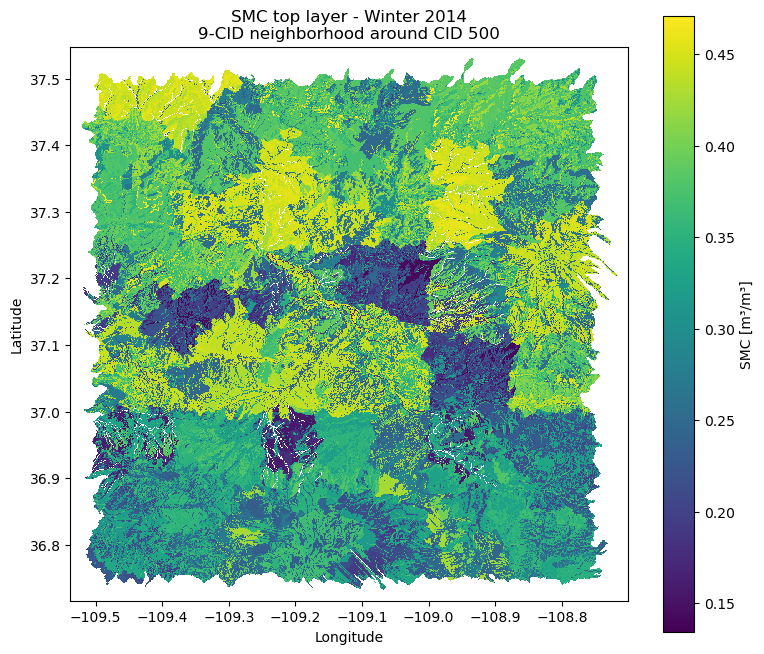

In [1]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# paths
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

print("Simulation path:", path, flush=True)

# read hru and cid maps
hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

hrus = gdal_tools.read_raster(hrus_file).astype(np.int32)
cids = gdal_tools.read_raster(cids_file).astype(np.int32)

metad = gdal_tools.retrieve_metadata(hrus_file)
extent = [metad["minx"], metad["maxx"], metad["miny"], metad["maxy"]]

# settings
var = "smc"
season_name = "Winter"
season_months = (1, 2)

# 3x3 neighborhood around CID 500
cid_list = [
    459, 460, 461,
    499, 500, 501,
    539, 540, 541
]

# read time from input file
time_file = path + "1/input_file.nc"

with nc.Dataset(time_file) as fp:
    time = fp.groups["meteorology"].variables["time"][:]

start = pd.Timestamp("2014-01-01 00:00:00")

times = pd.Series(
    start + pd.to_timedelta(time, unit="h"),
    name="datetime"
)

season_index = (
    (times.dt.year == 2014) &
    (times.dt.month.isin(season_months))
).values

print("Total timesteps:", len(times))
print("First time:", times.iloc[0])
print("Last time :", times.iloc[-1])
print(f"{season_name} timesteps:", season_index.sum())

# make final map only for selected CIDs
selected_mask = np.isin(cids, cid_list) & (hrus != -9999)

rows_all, cols_all = np.where(selected_mask)

r0, r1 = rows_all.min(), rows_all.max()
c0, c1 = cols_all.min(), cols_all.max()

# add small buffer
buffer = 20
r0 = max(r0 - buffer, 0)
r1 = min(r1 + buffer, hrus.shape[0])
c0 = max(c0 - buffer, 0)
c1 = min(c1 + buffer, hrus.shape[1])

hrus_sub = hrus[r0:r1, c0:c1]
cids_sub = cids[r0:r1, c0:c1]

final_map = np.full(hrus_sub.shape, -9999.0, dtype=np.float32)

for cid in cid_list:

    print(f"Processing CID {cid}", flush=True)

    fp_path = path + f"output_data/{cid}/2014-01-01.nc"

    if not os.path.exists(fp_path):
        print(f"Missing: {fp_path}", flush=True)
        continue

    with nc.Dataset(fp_path) as fp:
        grp = fp.groups["data"]

        if var not in grp.variables:
            print(f"{var} missing in CID {cid}", flush=True)
            continue

        # smc(time, hru, soil)
        smc = np.array(grp.variables[var][:, :, 0], dtype=np.float32)

    smc[smc <= -9990] = np.nan

    data = np.nanmean(smc[season_index, :], axis=0)

    print(f"CID {cid} data min/max:", np.nanmin(data), np.nanmax(data))

    mask = (hrus_sub != -9999) & (cids_sub == cid)

    hru_ids = hrus_sub[mask].astype(np.int32)
    hru_index = hru_ids - 1

    valid = (hru_index >= 0) & (hru_index < len(data))

    rows, cols = np.where(mask)
    final_map[rows[valid], cols[valid]] = data[hru_index[valid]]

final_map[final_map == -9999.0] = np.nan

print("Final valid pixels:", np.sum(np.isfinite(final_map)))
print("Final min:", np.nanmin(final_map))
print("Final max:", np.nanmax(final_map))

# subset extent
xmin, xmax, ymin, ymax = extent

nx = hrus.shape[1]
ny = hrus.shape[0]

xres = (xmax - xmin) / nx
yres = (ymax - ymin) / ny

sub_extent = [
    xmin + c0 * xres,
    xmin + c1 * xres,
    ymax - r1 * yres,
    ymax - r0 * yres
]

# plot
fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    final_map,
    origin="upper",
    extent=sub_extent,
    cmap="viridis",
    interpolation="nearest"
)

ax.set_title(f"SMC top layer - {season_name} 2014\n9-CID neighborhood around CID 500")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.colorbar(im, ax=ax, label="SMC [m³/m³]")

outfile = os.path.join(
    outputdir,
    f"smc_top_layer_{season_name}_2014_9cid_around_500.png"
)

plt.savefig(outfile, dpi=250, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()